# Imports

In [1]:
import sys
import os
import mne

sys.path.append(os.path.abspath('../src'))
from B_EEG_Preprocessing.load_raw import load_raw
from B_EEG_Preprocessing.set_montage_and_check import set_montage_and_check
from B_EEG_Preprocessing.basic_filtering import basic_filtering
from B_EEG_Preprocessing.detect_bad_channels import detect_bad_channels
from B_EEG_Preprocessing.ica_artefact_removal import ica_artefact_removal
from B_EEG_Preprocessing.save_eeg_cleaning_results import save_eeg_cleaning_results
from B_EEG_Preprocessing.ica_artefact_removal import plot_ica_before_after

# Variables

In [2]:
subjectID = 'Pilote001'
date      = '2026-07-09'
task      = 'Task2_HitOrMiss'
data_path =  '/Users/floremunier/Library/CloudStorage/Dropbox-NeuroRestore/Flore Munier-Jolain/PercepPD/Data'
file_name = f"{subjectID}_{date}_{task}"

### Load Data

In [4]:
vhdr_file_path = os.path.join(data_path , subjectID, task, 'Raw', 'EEG', file_name + ".vhdr")   
raw = load_raw(vhdr_file_path)

[load_raw] Pilote001_2026-07-09_Task2_HitOrMiss.vhdr
  Channels : 88  — first 5: ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3']
  Duration : 1678.5 s  |  Sfreq: 1000.0 Hz


### Set montage

[set_montage_and_check] Montage : 'standard_1020'
  Recognised (63) : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'O2', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FCz', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CP4', 'P5', 'P1', 'P2', 'P6', 'PO5', 'PO3', 'PO4', 'PO6', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Oz']
  Not in montage (25) : ['EOG', 'BIP1', 'BIP2', 'BIP3', 'BIP4', 'BIP5', 'BIP6', 'BIP7', 'BIP8', 'BIP9', 'BIP10', 'BIP11', 'BIP12', 'BIP13', 'BIP14', 'BIP15', 'BIP16', 'BIP17', 'BIP18', 'BIP19', 'BIP20', 'BIP21', 'BIP22', 'BIP23', 'BIP24']
  → Dropping 25 unrecognised channel(s).


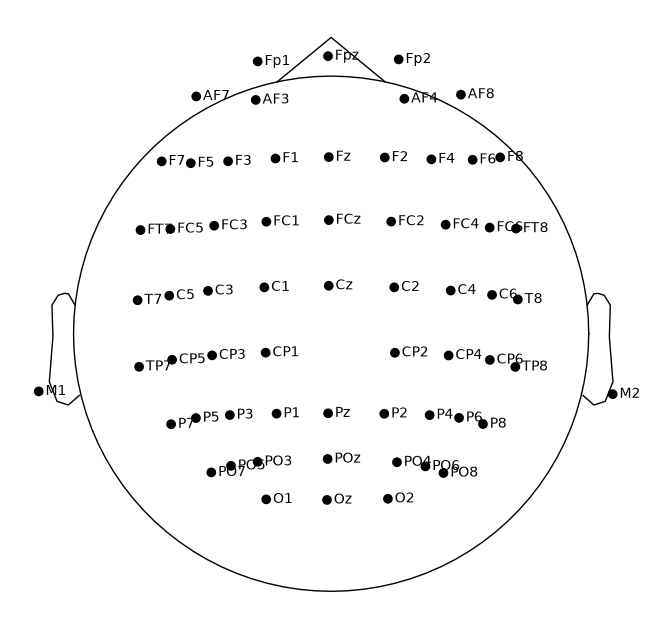

In [5]:
raw_montage = set_montage_and_check(raw)

### Basic filtering

In [ ]:
raw_filt = basic_filtering(
    raw_montage,
    l_freq=0.1,        # high-pass  (use 1.0 for cleaner ERPs)
    h_freq=80.0,       # low-pass
    notch_freq=50.0,   # power-line (50 Hz in Europe)
    reference=None,    # e.g. "average" for CAR, or a channel name
)

### Check bad channels

In [ ]:
raw_filt, bad_report = detect_bad_channels(raw_filt)   # marks raw_filt.info["bads"]

### ICA cleaning

In [ ]:
# Set y-axis scale
desired_scale_v = 200 * 1e-6
scale = {'eeg': desired_scale_v}
total_duration = raw_filt.times[-1]
raw_filt.plot(start=20, duration=1580, scalings=scale, overview_mode='hidden', show_scrollbars=False, n_channels=len(raw_filt.ch_names));

In [ ]:
# Keep clean part of the reccording to fit the ICA
# segments2keep = [(50, 1200), (1300,1800)] # Pilote001 Task1
segments2keep = [(20, 1580)] # Pilote001 Task2

# Compute the number of components to use for this analysis
n_good_channels = len(mne.pick_types(raw_filt.info, eeg=True, exclude="bads"))
n_components = n_good_channels - 1

raw_clean, ica, excluded, component_labels  = ica_artefact_removal(
    raw_filt,
    ica_segments=segments2keep,
    n_components=n_components,        # let MNE infer from data rank — safest
    method="infomax",       # extended Infomax is set automatically inside the function
    label_threshold=0.8, # conservative; lower to 0.7 if you feel artefacts are slipping through
    montage=raw_filt.get_montage()
)

In [ ]:
fig = plot_ica_before_after(
    raw_before=raw_filt,
    raw_after=raw_clean,
    tmin=40,
    tmax=100,
    n_channels=10,
    random_state=42
)

### Save clean signals

In [ ]:
save_eeg_cleaning_results(
    file_path=os.path.join(data_path, subjectID, task,'Output','clean_EEG'),
    file_name=f"{subjectID}_{date}_{task}",
    raw_clean=raw_clean,
    ica=ica
)